# <font color='cornflowerblue'>Child Mind Insitute Problematic Internet Use Approach UM - Data Team Club

In the third UM Data Team Club project, we'll predict the level of problematic internet usage exhibited by children and adolescents. The goal of this project is to develop a predictive model that analyzes children's physical activity and fitness data to identify early signs of problematic internet use.

<nav>
<a href=”https://uy.linkedin.com/company/data-team-club?trk=public_post_feed-actor-image">LinkedIn</a> |
<a href=”https://github.com/datateamclub”>Github</a>
</nav>

## Contents Table
 - [Imports](#1)
 - [Load Data](#3)
 - [Exploratory Data Analysis](#4)
     - [Severity Impairment Index Analysis](#4.1)
 - [Data Preprocessing](#5)
 - [Model](#6)

### Imports <a id='1'></a>

In [233]:
import numpy as np
import missingno as msno 
import math
import os
import pandas as pd
pd.set_option('display.max_columns', None)

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

import warnings
warnings.filterwarnings('ignore')

### Load Data <a id='3'></a>

In [234]:
df_train = pd.read_csv('/kaggle/input/child-mind-institute-problematic-internet-use/train.csv')
df_train.head()

,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Physical-HeartRate,Physical-Systolic_BP,Fitness_Endurance-Season,Fitness_Endurance-Max_Stage,Fitness_Endurance-Time_Mins,Fitness_Endurance-Time_Sec,FGC-Season,FGC-FGC_CU,FGC-FGC_CU_Zone,FGC-FGC_GSND,FGC-FGC_GSND_Zone,FGC-FGC_GSD,FGC-FGC_GSD_Zone,FGC-FGC_PU,FGC-FGC_PU_Zone,FGC-FGC_SRL,FGC-FGC_SRL_Zone,FGC-FGC_SRR,FGC-FGC_SRR_Zone,FGC-FGC_TL,FGC-FGC_TL_Zone,BIA-Season,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_BMI,BIA-BIA_BMR,BIA-BIA_DEE,BIA-BIA_ECW,BIA-BIA_FFM,BIA-BIA_FFMI,BIA-BIA_FMI,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_ICW,BIA-BIA_LDM,BIA-BIA_LST,BIA-BIA_SMM,BIA-BIA_TBW,PAQ_A-Season,PAQ_A-PAQ_A_Total,PAQ_C-Season,PAQ_C-PAQ_C_Total,PCIAT-Season,PCIAT-PCIAT_01,PCIAT-PCIAT_02,PCIAT-PCIAT_03,PCIAT-PCIAT_04,PCIAT-PCIAT_05,PCIAT-PCIAT_06,PCIAT-PCIAT_07,PCIAT-PCIAT_08,PCIAT-PCIAT_09,PCIAT-PCIAT_10,PCIAT-PCIAT_11,PCIAT-PCIAT_12,PCIAT-PCIAT_13,PCIAT-PCIAT_14,PCIAT-PCIAT_15,PCIAT-PCIAT_16,PCIAT-PCIAT_17,PCIAT-PCIAT_18,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,sii
0,00008ff9,Fall,5,0,Winter,51.0,Fall,16.877316,46.0,50.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Fall,0.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,7.0,0.0,6.0,0.0,6.0,1.0,Fall,2.0,2.66855,16.8792,932.498,1492.00,8.25598,41.5862,13.8177,3.06143,9.21377,1.0,24.4349,8.89536,38.9177,19.5413,32.6909,NaN,NaN,NaN,NaN,Fall,5.0,4.0,4.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0,4.0,0.0,4.0,4.0,4.0,4.0,4.0,4.0,2.0,4.0,55.0,NaN,NaN,NaN,Fall,3.0,2.0
1,000fd460,Summer,9,0,NaN,NaN,Fall,14.035590,48.0,46.0,22.0,75.0,70.0,122.0,NaN,NaN,NaN,NaN,Fall,3.0,0.0,NaN,NaN,NaN,NaN,5.0,0.0,11.0,1.0,11.0,1.0,3.0,0.0,Winter,2.0,2.57949,14.0371,936.656,1498.65,6.01993,42.0291,12.8254,1.21172,3.97085,1.0,21.0352,14.97400,39.4497,15.4107,27.0552,NaN,NaN,Fall,2.340,Fall,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Fall,46.0,64.0,Summer,0.0,0.0
2,00105258,Summer,10,1,Fall,71.0,Fall,16.648696,56.5,75.6,NaN,65.0,94.0,117.0,Fall,5.0,7.0,33.0,Fall,20.0,1.0,10.2,1.0,14.7,2.0,7.0,1.0,10.0,1.0,10.0,1.0,5.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Summer,2.170,Fall,5.0,2.0,2.0,1.0,2.0,1.0,1.0,2.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,2.0,2.0,1.0,1.0,28.0,Fall,38.0,54.0,Summer,2.0,0.0
3,00115b9f,Winter,9,0,Fall,71.0,Summer,18.292347,56.0,81.6,NaN,60.0,97.0,117.0,Summer,6.0,9.0,37.0,Summer,18.0,1.0,NaN,NaN,NaN,NaN,5.0,0.0,7.0,0.0,7.0,0.0,7.0,1.0,Summer,3.0,3.84191,18.2943,1131.430,1923.44,15.59250,62.7757,14.0740,4.22033,18.82430,2.0,30.4041,16.77900,58.9338,26.4798,45.9966,NaN,NaN,Winter,2.451,Summer,4.0,2.0,4.0,0.0,5.0,1.0,0.0,3.0,2.0,2.0,3.0,0.0,3.0,0.0,0.0,3.0,4.0,3.0,4.0,1.0,44.0,Summer,31.0,45.0,Winter,0.0,1.0
4,0016bb22,Spring,18,1,Summer,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Summer,1.04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [235]:
df_test = pd.read_csv('/kaggle/input/child-mind-institute-problematic-internet-use/test.csv')

### **Target Variable (SII)**

- **0: None**  
  *PCIAT-PCIAT_Total from 0 to 30*
- **1: Mild**  
  *PCIAT-PCIAT_Total from 31 to 49*
- **2: Moderate**  
  *PCIAT-PCIAT_Total from 50 to 79*
- **3: Severe**  
  *PCIAT-PCIAT_Total 80 and more*

### Exploratory Data Analysis <a id='4'></a>

In [236]:
df_train.shape

(3960, 82)

In [237]:
(df_train.isna().mean() * 100).sort_values(ascending=False).head(15)

PAQ_A-PAQ_A_Total               88.005051
PAQ_A-Season                    88.005051
Fitness_Endurance-Time_Sec      81.313131
Fitness_Endurance-Time_Mins     81.313131
Fitness_Endurance-Max_Stage     81.237374
Physical-Waist_Circumference    77.323232
FGC-FGC_GSND_Zone               73.181818
FGC-FGC_GSD_Zone                73.156566
FGC-FGC_GSD                     72.878788
FGC-FGC_GSND                    72.878788
Fitness_Endurance-Season        66.969697
PAQ_C-Season                    56.540404
PAQ_C-PAQ_C_Total               56.540404
BIA-BIA_DEE                     49.722222
BIA-BIA_FFM                     49.722222
dtype: float64

In [238]:
df_train.select_dtypes(include=['number']).corr()['sii'][25:].sort_values(ascending=False)

sii                                       1.000000
PCIAT-PCIAT_Total                         0.899681
PCIAT-PCIAT_15                            0.751399
PCIAT-PCIAT_18                            0.731112
PCIAT-PCIAT_17                            0.729867
PCIAT-PCIAT_05                            0.722722
PCIAT-PCIAT_13                            0.705679
PCIAT-PCIAT_20                            0.703013
PCIAT-PCIAT_16                            0.698566
PCIAT-PCIAT_08                            0.695458
PCIAT-PCIAT_03                            0.694736
PCIAT-PCIAT_02                            0.694597
PCIAT-PCIAT_10                            0.689972
PCIAT-PCIAT_19                            0.683293
PCIAT-PCIAT_14                            0.675953
PCIAT-PCIAT_09                            0.660485
PCIAT-PCIAT_06                            0.645596
PCIAT-PCIAT_01                            0.617883
PCIAT-PCIAT_11                            0.609964
PCIAT-PCIAT_04                 

<Axes: >

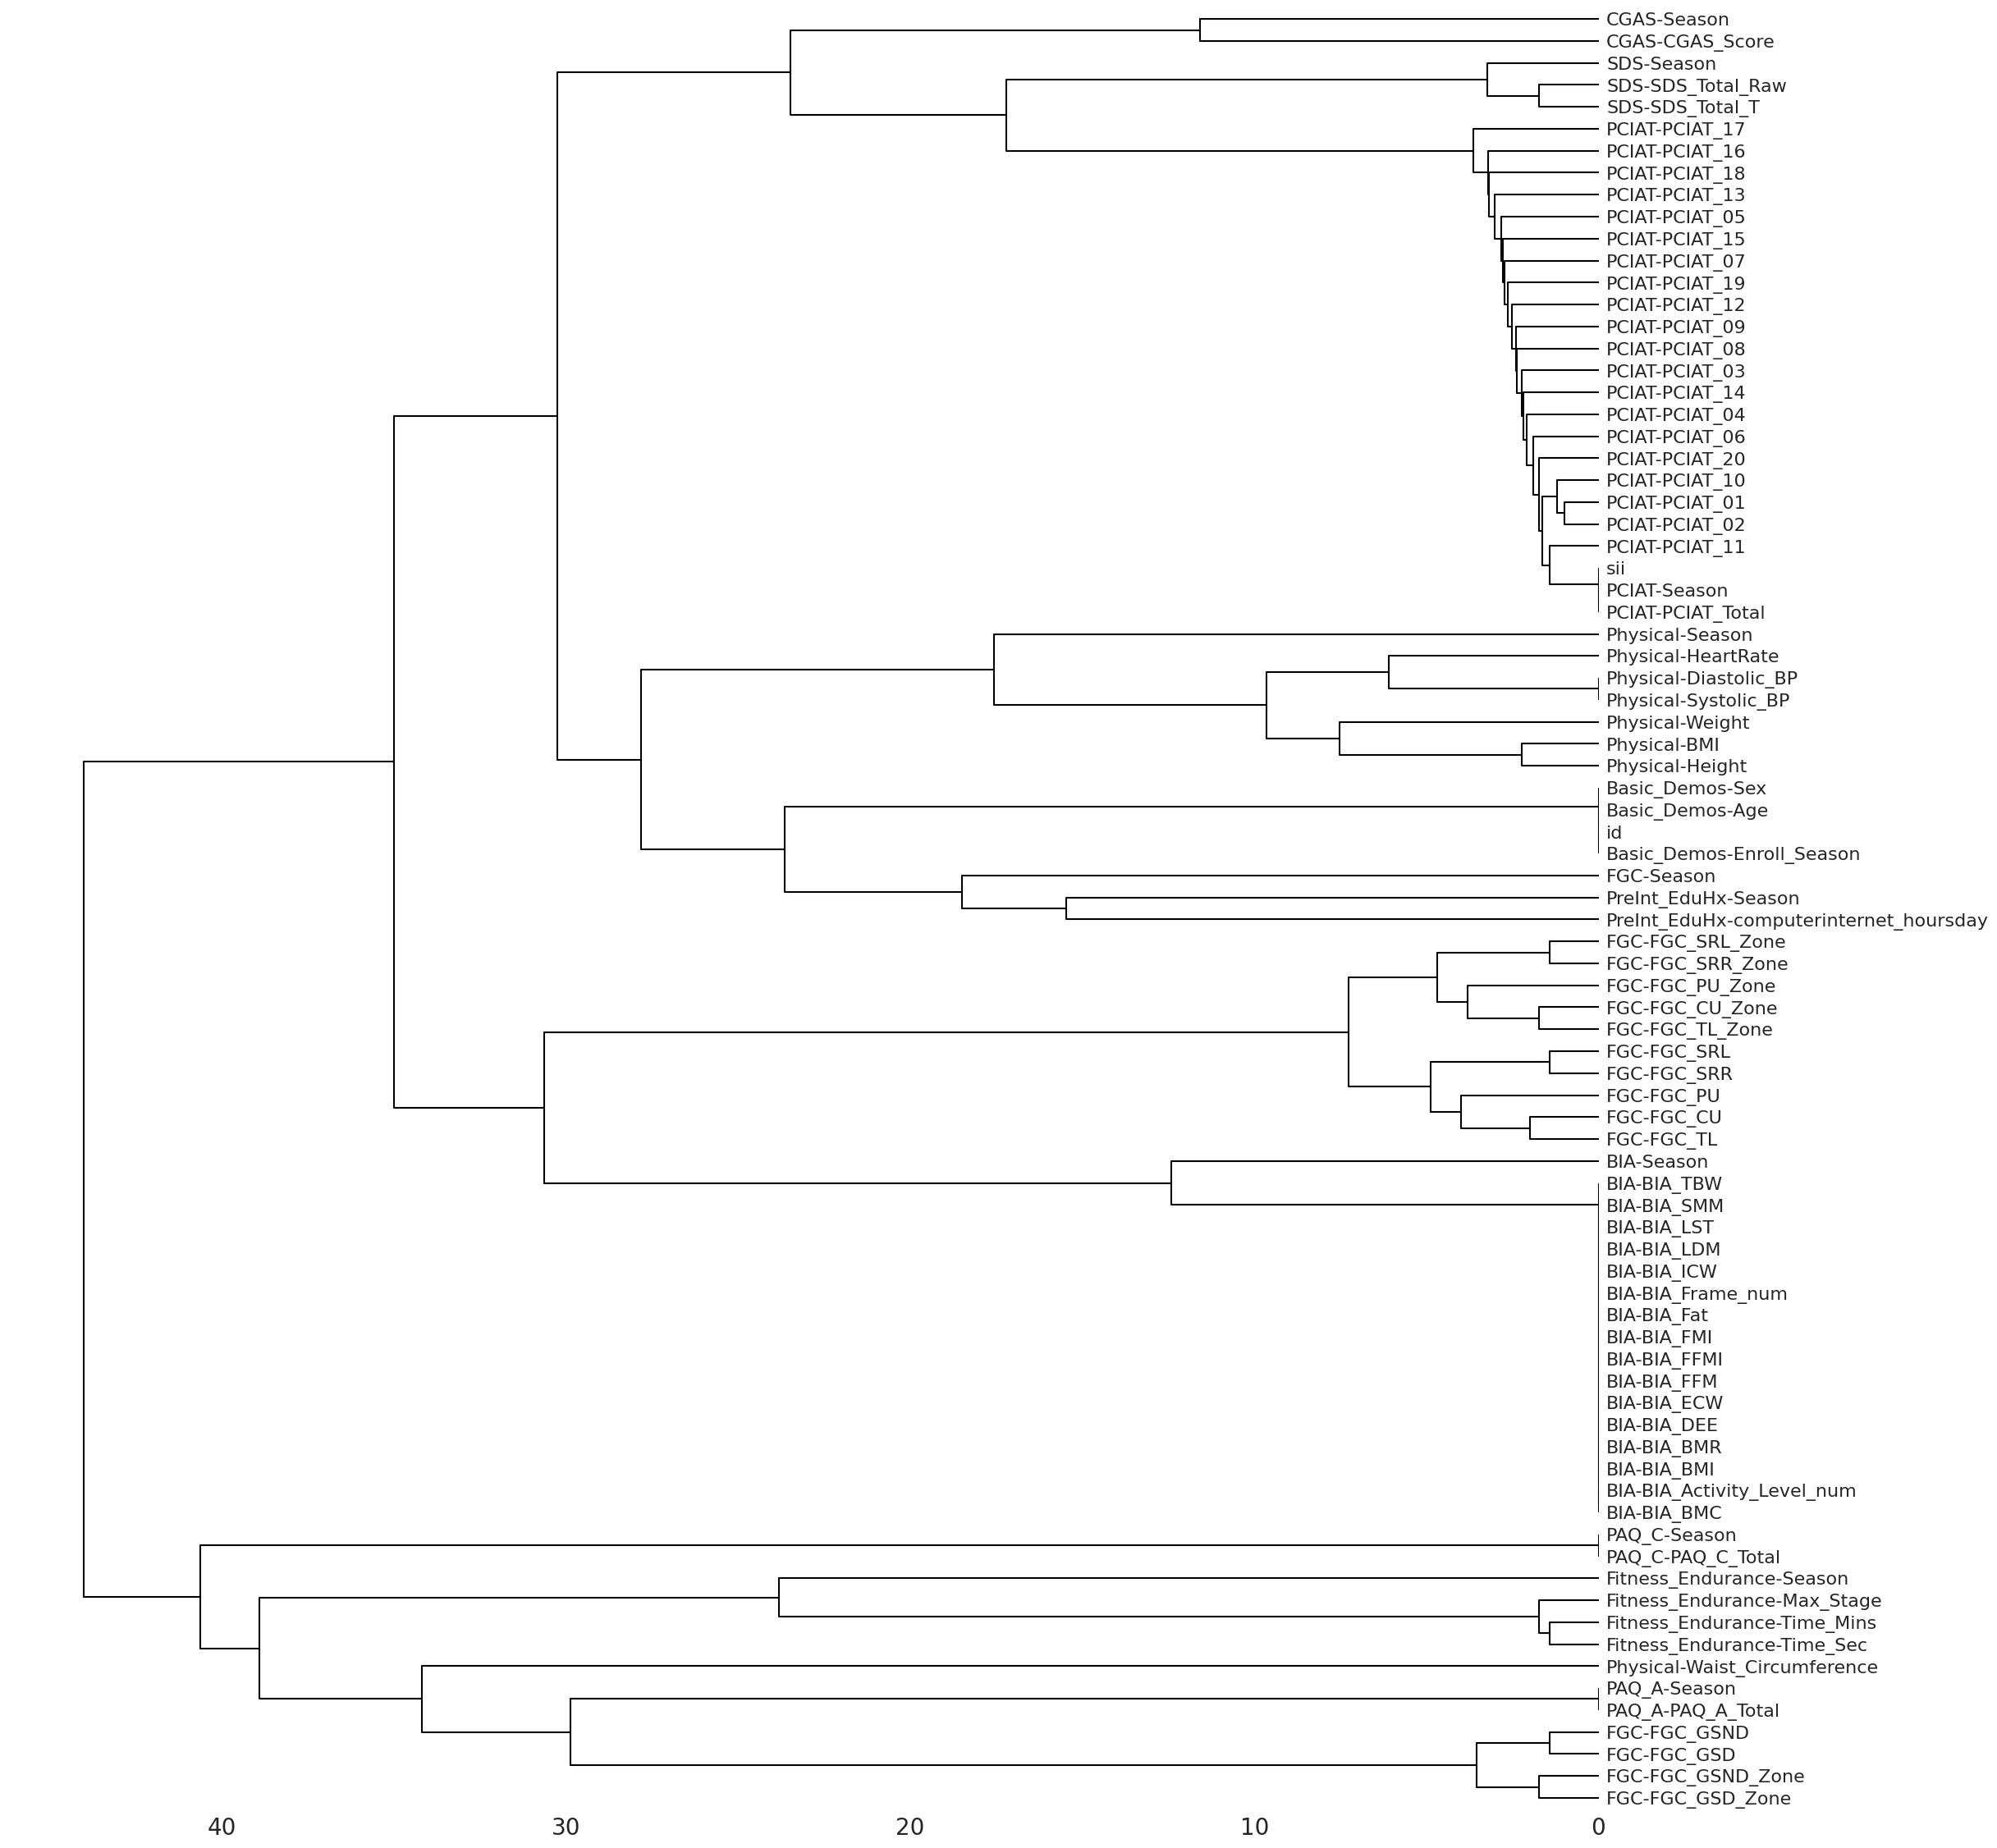

In [239]:
msno.dendrogram(df_train)

<div class="alert alert-block alert-info">
<b></b> We will review the columns available in the test dataframe to ensure predictions can be made without relying on variables that are missing.</div>



In [240]:
columns_useful_to_predict = [col for col in list(df_train.columns) if col in list(df_test.columns)]

print(f'The variables available for prediction are: \n {columns_useful_to_predict}, being in total {len(columns_useful_to_predict)}.')

The variables available for prediction are: 
 ['id', 'Basic_Demos-Enroll_Season', 'Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-Season', 'CGAS-CGAS_Score', 'Physical-Season', 'Physical-BMI', 'Physical-Height', 'Physical-Weight', 'Physical-Waist_Circumference', 'Physical-Diastolic_BP', 'Physical-HeartRate', 'Physical-Systolic_BP', 'Fitness_Endurance-Season', 'Fitness_Endurance-Max_Stage', 'Fitness_Endurance-Time_Mins', 'Fitness_Endurance-Time_Sec', 'FGC-Season', 'FGC-FGC_CU', 'FGC-FGC_CU_Zone', 'FGC-FGC_GSND', 'FGC-FGC_GSND_Zone', 'FGC-FGC_GSD', 'FGC-FGC_GSD_Zone', 'FGC-FGC_PU', 'FGC-FGC_PU_Zone', 'FGC-FGC_SRL', 'FGC-FGC_SRL_Zone', 'FGC-FGC_SRR', 'FGC-FGC_SRR_Zone', 'FGC-FGC_TL', 'FGC-FGC_TL_Zone', 'BIA-Season', 'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_BMI', 'BIA-BIA_BMR', 'BIA-BIA_DEE', 'BIA-BIA_ECW', 'BIA-BIA_FFM', 'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num', 'BIA-BIA_ICW', 'BIA-BIA_LDM', 'BIA-BIA_LST', 'BIA-BIA_SMM', 'BIA-BIA_TBW', 'PAQ_A-Season', 'PA

### **Severity Impairment Index Analysis** <a id="4.1"></a>

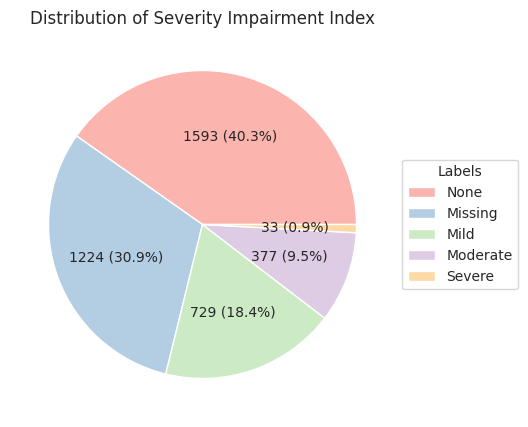

In [241]:
labels_map = {0: 'None', 1: 'Mild', 2: 'Moderate', 3: 'Severe', -1: 'Missing'}
label_counts = df_train['sii'].map(lambda x: labels_map.get(x, 'Missing')).value_counts()

def func(pct, allvals):
    absolute = int(pct / 100. * sum(allvals))
    return f"{absolute} ({pct:.1f}%)"

plt.figure(figsize=(10, 5))
wedges, texts, autotexts = plt.pie(
    label_counts, 
    autopct=lambda pct: func(pct, label_counts), 
    labels=[None] * len(label_counts), 
    colors=plt.cm.Pastel1.colors)

plt.legend(
    wedges, 
    label_counts.index, 
    title="Labels", 
    loc="center left", 
    bbox_to_anchor=(1, 0.5)
)
plt.title("Distribution of Severity Impairment Index")
display()

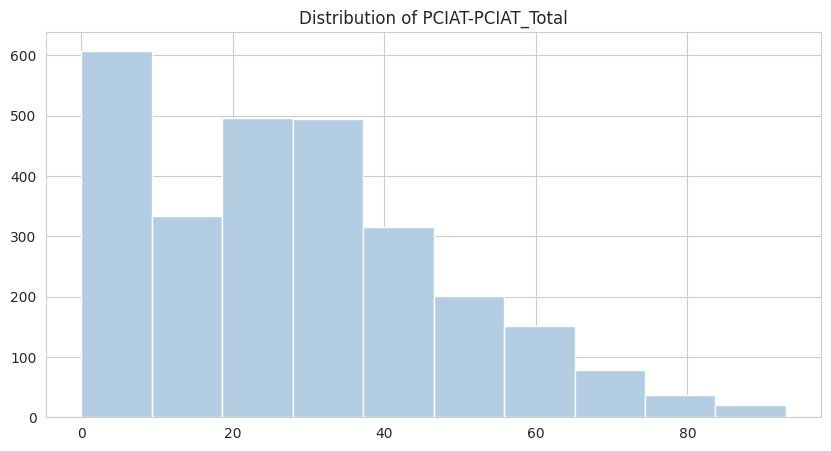

In [242]:
plt.figure(figsize=(10, 5))
n, bins, patches = plt.hist(
    df_train['PCIAT-PCIAT_Total'], 
    bins=10,
    color = plt.cm.Pastel1.colors[1])

plt.title("Distribution of PCIAT-PCIAT_Total")
display()

#### Is there an association between gender and the Severity Impairment Index?

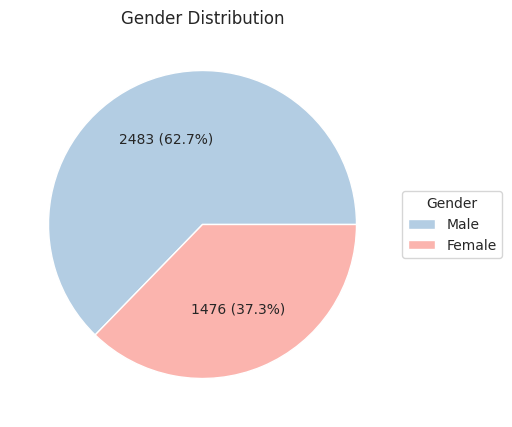

In [243]:
colors = [plt.cm.Pastel1.colors[1], plt.cm.Pastel1.colors[0]]
gender_labels = {0: 'Male', 1: 'Female'}
gender_counts = df_train['Basic_Demos-Sex'].map(lambda x: gender_labels.get(x, 'Unknown')).value_counts()

plt.figure(figsize=(10, 5))
wedges, texts, autotexts = plt.pie(
    gender_counts, 
    autopct=lambda pct: func(pct, gender_counts), 
    labels=[None] * len(gender_counts), 
    colors=colors
)

plt.legend(
    wedges, 
    gender_counts.index, 
    title="Gender", 
    loc="center left", 
    bbox_to_anchor=(1, 0.5)
)

plt.title("Gender Distribution")
plt.show()

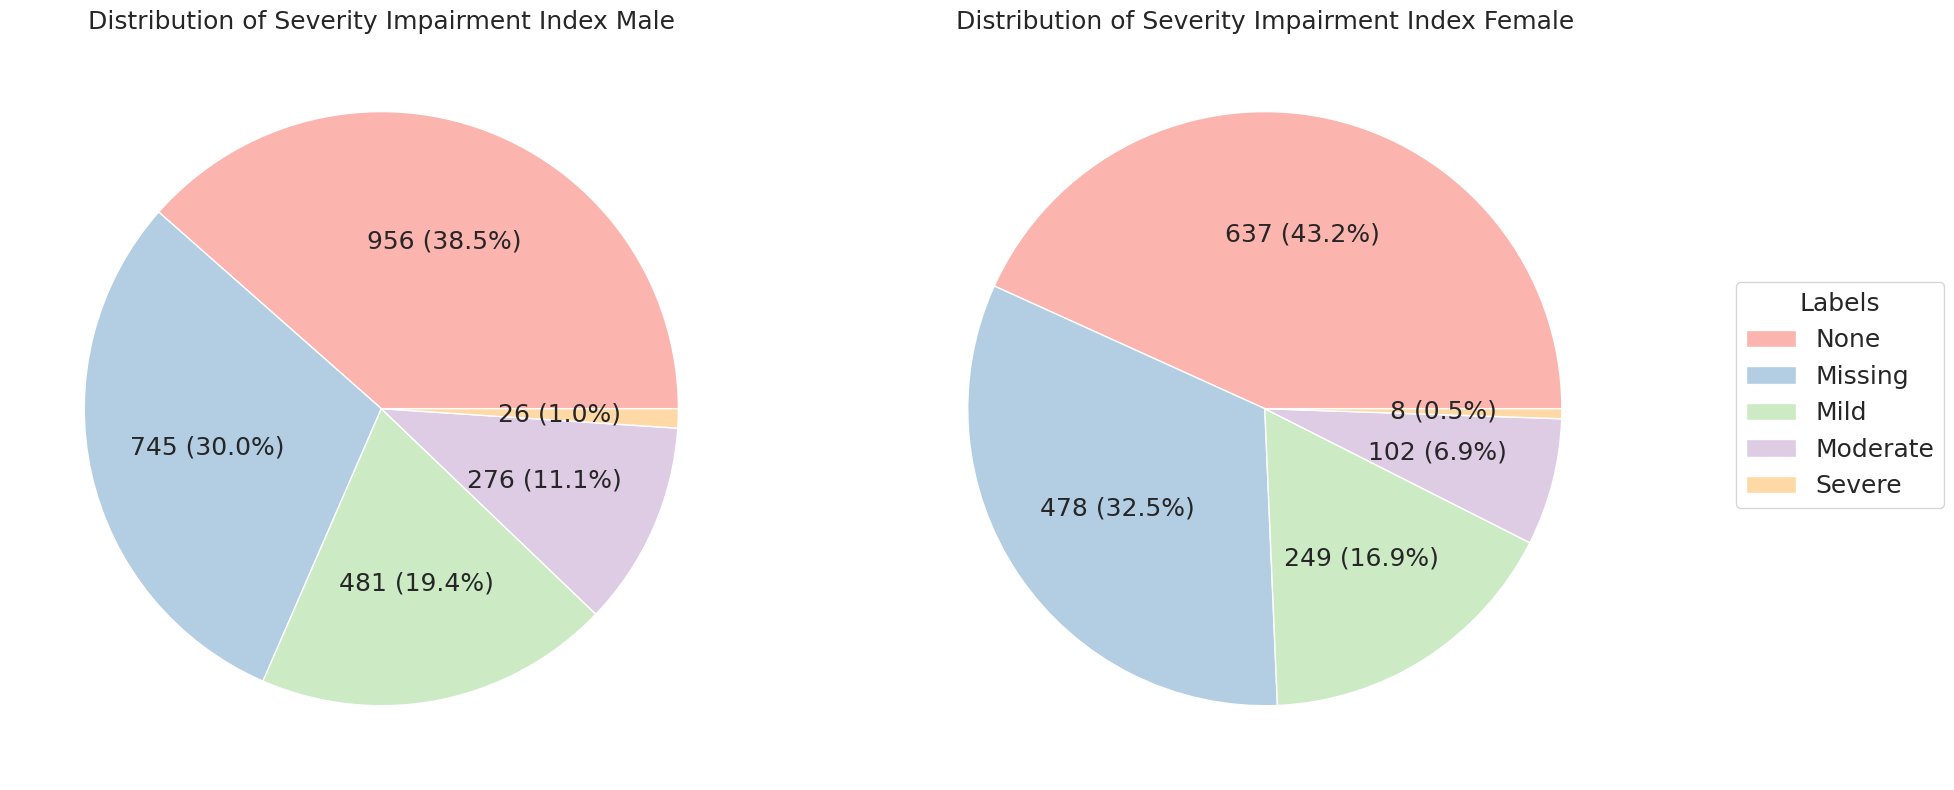

In [244]:
def plot_pie(data, gender_label, ax):
    label_counts = data['sii'].map(lambda x: labels_map.get(x, 'Missing')).value_counts()
    
    color_count = len(label_counts)
    pie_colors = colors[:color_count]

    wedges, texts, autotexts = ax.pie(
        label_counts, 
        autopct=lambda pct: func(pct, label_counts), 
        labels=[None] * len(label_counts), 
        colors=plt.cm.Pastel1.colors, 
        textprops={'fontsize': 18}
    )
    
    for autotext in autotexts:
        autotext.set_fontsize(18)
    
    ax.set_title(f"Distribution of Severity Impairment Index {gender_label}", fontsize=18)
    
    return wedges

fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True)

all_wedges = []
gender_labels_list = []

for i, (gender_value, gender_label) in enumerate(gender_labels.items()):
    gender_data = df_train[df_train['Basic_Demos-Sex'] == gender_value]
    wedges = plot_pie(gender_data, gender_label, axes[i])
    all_wedges.extend(wedges)
    gender_labels_list.append(gender_label)

fig.legend(
    all_wedges, 
    label_counts.index, 
    title="Labels", 
    loc="center left", 
    bbox_to_anchor=(1, 0.5),
    fontsize=18,
    title_fontsize=18
)

plt.tight_layout()
display()

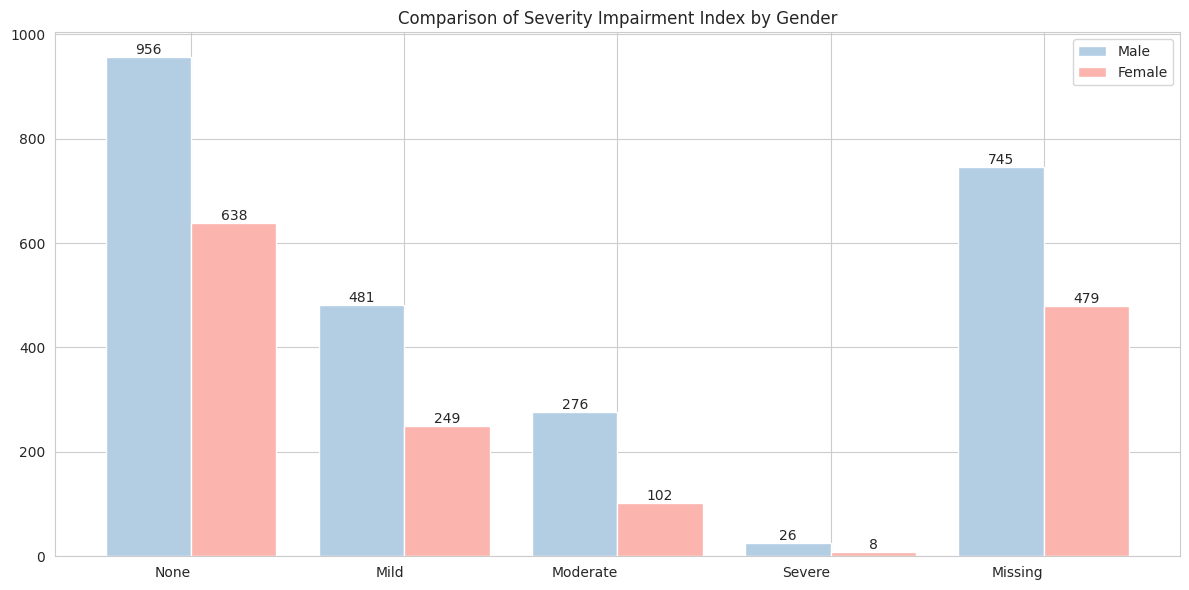

In [245]:
categories = list(labels_map.values())

male_values = (
    df_train[df_train['Basic_Demos-Sex'] == 0]['sii']
    .map(lambda x: labels_map.get(x, 'Missing'))
    .value_counts()
    .reindex(categories, fill_value=0)
)

female_values = (
    df_train[df_train['Basic_Demos-Sex'] == 1]['sii']
    .map(lambda x: labels_map.get(x, 'Missing'))
    .value_counts()
    .reindex(categories, fill_value=0)
)

x = np.arange(len(categories))
width = 0.4

fig, ax = plt.subplots(figsize=(12, 6))

bars_male = ax.bar(x - width / 2, male_values, width, label='Male', color=plt.cm.Pastel1.colors[1])
bars_female = ax.bar(x + width / 2, female_values, width, label='Female', color=plt.cm.Pastel1.colors[0])

ax.set_title('Comparison of Severity Impairment Index by Gender')
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=0, ha='right')
ax.legend()

for bars in (bars_male, bars_female):
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2, 
                height, 
                str(height), 
                ha='center', 
                va='bottom'
            )

plt.tight_layout()
display()

<div class="alert alert-block alert-info">
<b></b> Overall, the data indicates that males have a slightly higher likelihood of being categorized under the "Mild," "Moderate," and "Severe" levels of impairment compared to females, while females are more likely to fall into the "None" category. These findings suggest a potential relationship between gender and the Severity Impairment Index (SII). Further analysis will be conducted, incorporating other variables, to gain a deeper understanding of the factors influencing the Severity Impairment Index.</div>

#### How does the distribution of the SII vary across different age groups?

To conclude the analysis of the demographic variables, it is important to examine the age of the children and adolescents to determine if there is a relationship with the Severity Impairment Index. Understanding how SII varies across age groups can provide insights into potential trends or patterns related to developmental stages.

In [246]:
df_train['Basic_Demos-Age'].describe()

count    3960.000000
mean       10.433586
std         3.574648
min         5.000000
25%         8.000000
50%        10.000000
75%        13.000000
max        22.000000
Name: Basic_Demos-Age, dtype: float64

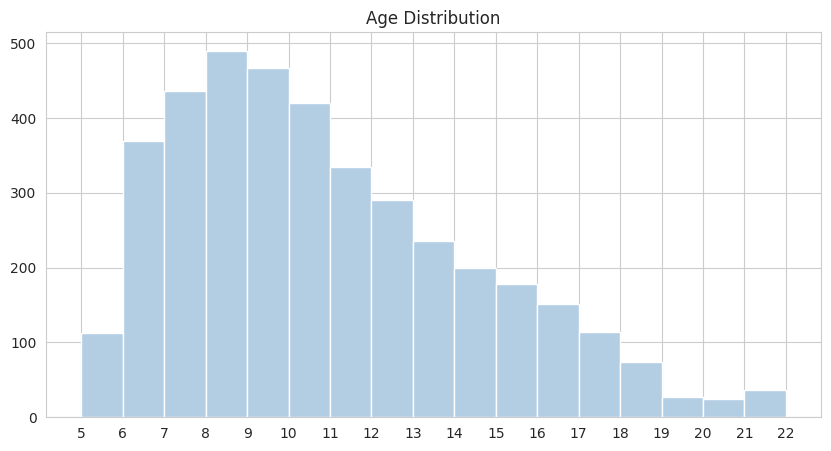

In [247]:
plt.figure(figsize=(10, 5))
plt.hist(df_train['Basic_Demos-Age'], color=plt.cm.Pastel1.colors[1], bins=range(int(df_train['Basic_Demos-Age'].min()), 
               int(df_train['Basic_Demos-Age'].max()) + 1))

plt.title("Age Distribution")
plt.xticks(np.arange(int(df_train['Basic_Demos-Age'].min()), int(df_train['Basic_Demos-Age'].max()) + 1, step=1))
display()

## Modelado basico

In [248]:
columns_to_encode = [col for col in df_train.columns if "Season" in col]
# Realizar one-hot encoding
df_encoded_train = pd.get_dummies(df_train, columns=columns_to_encode)

columns_to_encode = [col for col in df_test.columns if "Season" in col]
# Realizar one-hot encoding
df_encoded_test = pd.get_dummies(df_test, columns=columns_to_encode)

In [249]:
columns_useful_to_predict = [col for col in list(df_encoded_train.columns) if col in list(df_encoded_test.columns)]
print(df_encoded_train.shape)
df_encoded_train = df_encoded_train[columns_useful_to_predict + ['sii', 'PCIAT-PCIAT_Total']]
print(df_encoded_train.shape)

(3960, 115)
(3960, 86)


In [250]:
df_encoded_train = df_encoded_train.drop(columns=['id'])

Hay que hacer tratamiento de valores faltantes, capaz un knn.

In [251]:
from sklearn.impute import KNNImputer

df_encoded = df_encoded_train.dropna(subset=['sii'])

X = df_encoded.drop(columns = ['sii', 'PCIAT-PCIAT_Total'])
y = df_encoded['sii']  

imputer = KNNImputer(n_neighbors=3)  # Puedes ajustar el número de vecinos
X_imputed = imputer.fit_transform(X)

In [252]:
X

,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Physical-HeartRate,Physical-Systolic_BP,Fitness_Endurance-Max_Stage,Fitness_Endurance-Time_Mins,Fitness_Endurance-Time_Sec,FGC-FGC_CU,FGC-FGC_CU_Zone,FGC-FGC_GSND,FGC-FGC_GSND_Zone,FGC-FGC_GSD,FGC-FGC_GSD_Zone,FGC-FGC_PU,FGC-FGC_PU_Zone,FGC-FGC_SRL,FGC-FGC_SRL_Zone,FGC-FGC_SRR,FGC-FGC_SRR_Zone,FGC-FGC_TL,FGC-FGC_TL_Zone,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_BMI,BIA-BIA_BMR,BIA-BIA_DEE,BIA-BIA_ECW,BIA-BIA_FFM,BIA-BIA_FFMI,BIA-BIA_FMI,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_ICW,BIA-BIA_LDM,BIA-BIA_LST,BIA-BIA_SMM,BIA-BIA_TBW,PAQ_A-PAQ_A_Total,PAQ_C-PAQ_C_Total,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,Basic_Demos-Enroll_Season_Fall,Basic_Demos-Enroll_Season_Spring,Basic_Demos-Enroll_Season_Summer,Basic_Demos-Enroll_Season_Winter,CGAS-Season_Fall,CGAS-Season_Spring,CGAS-Season_Summer,CGAS-Season_Winter,Physical-Season_Fall,Physical-Season_Spring,Physical-Season_Summer,Physical-Season_Winter,Fitness_Endurance-Season_Fall,Fitness_Endurance-Season_Spring,Fitness_Endurance-Season_Summer,FGC-Season_Fall,FGC-Season_Spring,FGC-Season_Summer,FGC-Season_Winter,BIA-Season_Fall,BIA-Season_Summer,BIA-Season_Winter,PAQ_A-Season_Summer,PAQ_C-Season_Fall,PAQ_C-Season_Spring,PAQ_C-Season_Summer,PAQ_C-Season_Winter,SDS-Season_Fall,SDS-Season_Spring,SDS-Season_Summer,SDS-Season_Winter,PreInt_EduHx-Season_Fall,PreInt_EduHx-Season_Spring,PreInt_EduHx-Season_Summer,PreInt_EduHx-Season_Winter
0,5,0,51.0,16.877316,46.0,50.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,7.0,0.0,6.0,0.0,6.0,1.0,2.0,2.66855,16.8792,932.498,1492.00,8.25598,41.5862,13.8177,3.061430,9.21377,1.0,24.4349,8.89536,38.9177,19.5413,32.6909,NaN,NaN,NaN,NaN,3.0,True,False,False,False,False,False,False,True,True,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,9,0,NaN,14.035590,48.0,46.0,22.0,75.0,70.0,122.0,NaN,NaN,NaN,3.0,0.0,NaN,NaN,NaN,NaN,5.0,0.0,11.0,1.0,11.0,1.0,3.0,0.0,2.0,2.57949,14.0371,936.656,1498.65,6.01993,42.0291,12.8254,1.211720,3.97085,1.0,21.0352,14.97400,39.4497,15.4107,27.0552,NaN,2.340,46.0,64.0,0.0,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True,False,True,False,False,False,True,False,False,False,False,False,True,False
2,10,1,71.0,16.648696,56.5,75.6,NaN,65.0,94.0,117.0,5.0,7.0,33.0,20.0,1.0,10.2,1.0,14.7,2.0,7.0,1.0,10.0,1.0,10.0,1.0,5.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.170,38.0,54.0,2.0,False,False,True,False,True,False,False,False,True,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False
3,9,0,71.0,18.292347,56.0,81.6,NaN,60.0,97.0,117.0,6.0,9.0,37.0,18.0,1.0,NaN,NaN,NaN,NaN,5.0,0.0,7.0,0.0,7.0,0.0,7.0,1.0,3.0,3.84191,18.2943,1131.430,1923.44,15.59250,62.7757,14.0740,4.220330,18.82430,2.0,30.4041,16.77900,58.9338,26.4798,45.9966,NaN,2.451,31.0,45.0,0.0,False,False,False,True,True,False,False,False,False,False,True,False,False,False,True,False,False,True,False,False,True,False,False,False,False,False,True,False,False,True,False,False,False,False,True
5,13,1,50.0,22.279952,59.5,112.2,NaN,60.0,73.0,102.0,NaN,NaN,NaN,12.0,0.0,16.5,2.0,17.9,2.0,6.0,0.0,10.0,1.0,11.0,1.0,8.0,0.0,2.0,4.33036,30.1865,1330.970,1996.45,30.21240,84.0285,16.6877,13.498800,67.97150,2.0,32.9141,20.90200,79.6982,35.3804,63.1265,NaN,4.110,40.0,56.0,0.0,False,True,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False,True,False,False,False,True,False,False,False,False,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...

In [253]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
            
X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.3, random_state=42)

# Crear y entrenar el modelo (Random Forest como ejemplo)
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Hacer predicciones
y_pred = model.predict(X_test)

# Evaluar el modelo
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.6114494518879415

Classification Report:
               precision    recall  f1-score   support

         0.0       0.70      0.87      0.77       509
         1.0       0.32      0.28      0.30       193
         2.0       0.33      0.07      0.11       107
         3.0       0.00      0.00      0.00        12

    accuracy                           0.61       821
   macro avg       0.34      0.30      0.30       821
weighted avg       0.55      0.61      0.56       821



In [256]:
# predicciones con el primer modelo

df_submission = pd.DataFrame()

df_submission['id'] = df_test['id']
print(df_submission.shape)

# label encoding
columns_to_encode = [col for col in df_test.columns if "Season" in col]
df_encoded = pd.get_dummies(df_test, columns=columns_to_encode)

X = df_encoded.drop(columns = ['id'])

# manejo missing vals
imputer = KNNImputer(n_neighbors=3)  # Puedes ajustar el número de vecinos
X_imputed = imputer.fit_transform(X)

y_pred = model.predict(X_imputed)

df_submission['sii'] = y_pred

(20, 1)


In [262]:
df_submission['sii'] = df_submission['sii'].astype('int64')
df_submission

,id,sii
0,00008ff9,0
1,000fd460,0
2,00105258,0
3,00115b9f,1
4,0016bb22,1
5,001f3379,1
6,0038ba98,0
7,0068a485,0
8,0069fbed,1
9,0083e397,1


In [259]:
df_submission.to_csv('submission.csv')

In [ ]:
# Asegurarte de que df_submission tiene las filas correctas
if len(y_pred) == len(df_submission):
    df_submission['sii'] = y_pred
    print("Predicciones añadidas a df_submission.")
else:
    print(f"Error: El tamaño de y_pred ({len(y_pred)}) no coincide con las filas de df_submission ({len(df_submission)}).")


Vs una regresion

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y = df_encoded['PCIAT-PCIAT_Total']  

# Separar características y objetivo (ejemplo con X_imputed y y para regresión)
X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.3, random_state=42)

# Crear y entrenar el modelo de regresión lineal
model = LinearRegression()
model.fit(X_train, y_train)

# Hacer predicciones
y_pred = model.predict(X_test)

# Calcular métricas
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Imprimir resultados
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.2f}")
